## Exercise 3: Binary Classification with Different Decision Statistics

Consider a binary classification problem where $X = [X_1, X_2] \in \mathbb{R}^2$ is the feature vector and $Y \in \{-1, 1\}$ is the hypothesis (label).

### 1. Statistical Model

The features $X_1$ and $X_2$ are assumed to be **independent given the hypothesis** $Y$. The likelihoods and priors are defined as follows:

**Prior probabilities:** The hypotheses are uniform:
$$P(Y = +1) = P(Y = -1) = 0.5$$

**Likelihoods for $X_1$:**
$$\ell(x_1 \mid Y = +1) = \frac{1}{\sqrt{3\pi}} \exp\left( -\frac{(x_1 - 1)^2}{3} \right)$$
$$\ell(x_1 \mid Y = -1) = \frac{1}{\sqrt{0.6\pi}} \exp\left( -\frac{(x_1 - 1.5)^2}{0.6} \right)$$

**Likelihoods for $X_2$:**
$$\ell(x_2 \mid Y = +1) = \frac{1}{\sqrt{3\pi}} \exp\left( -\frac{(x_2 - 1)^2}{3} \right)$$
$$\ell(x_2 \mid Y = -1) = \frac{1}{\sqrt{0.6\pi}} \exp\left( -\frac{(x_2 + 1.5)^2}{0.6} \right)$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


prior_neg=0.5
prior_pos=0.5
sigma=1 #deviazione standart
N=20000
y_true = np.random.choice([-1, 1], size=N, p=[prior_neg, prior_pos])

x = np.zeros((N, 2))

index_pos = (y_true == 1)
index_neg = (y_true == -1)
mu_minus = [1.5, -1.5]
n_minus = np.sum(index_neg)
x[index_neg] = np.random.normal(loc=mu_minus, scale=1.0, size=(n_minus, 2))

# 3. Per Y = +1: X1 media -0.85, X2 media 0.9
mu_plus = [1, 1]
n_plus = np.sum(index_pos)
x[index_pos] = np.random.normal(loc=mu_plus, scale=1.0, size=(n_plus, 2))

In [9]:
print("Media X1 per Y=-1:", x[y_true == -1, 0].mean()) # Dovrebbe essere ~1.5
print("Media X2 per Y=-1:", x[y_true == -1, 1].mean()) # Dovrebbe essere ~-1.5

Media X1 per Y=-1: 1.4909145716510857
Media X2 per Y=-1: -1.4793001834907893


**Punto A**

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x,     #Rappresenta la matrice dei dati 
    y_true,     #La funzione deve dividere anche questo vettore nello stesso identico ordine di Dataset, in modo che ogni punto in D abbia ancora la sua etichetta corrispondente in y_train.
    test_size=0.25, 
    random_state=42,  #Assicura che la suddivisione sia riproducibile. Ogni volta che eseguirai il codice, otterrai gli stessi identici set di dati.
    stratify=y_true       #Questo parametro assicura che la proporzione tra le classi (rossi e blu) rimanga la stessa sia nel training che nel test set.
)  

# Verifica delle dimensioni
print(f"Dimensioni Training set: {X_train.shape} campioni")
print(f"Dimensioni Test set: {X_test.shape} campioni")


Dimensioni Training set: (15000, 2) campioni
Dimensioni Test set: (5000, 2) campioni


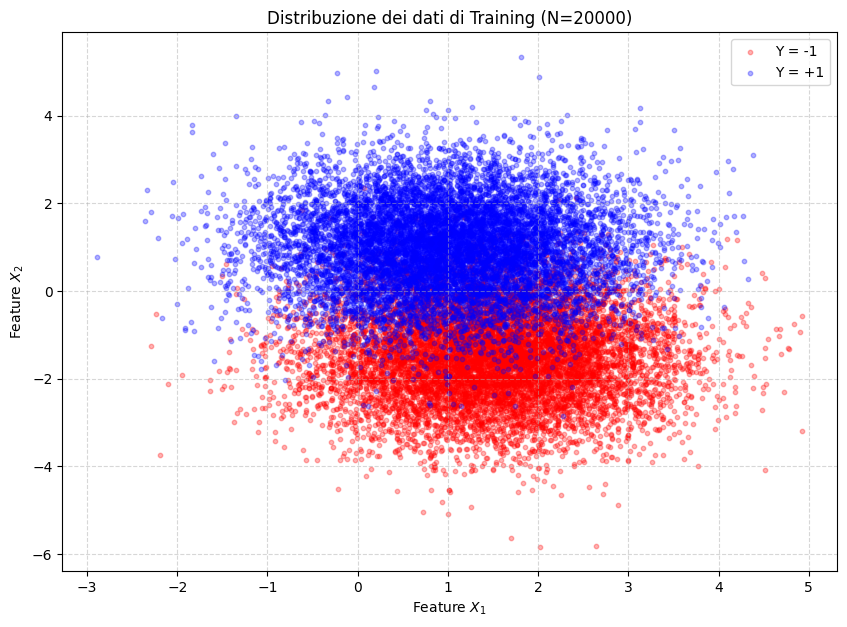

In [11]:
import matplotlib.pyplot as plt

# Supponendo che X_train e Y_train siano già stati generati
plt.figure(figsize=(10, 7))

# Plot dei punti per Y = -1 (Classe Rossa)
plt.scatter(x[y_true == -1, 0], x[y_true == -1, 1], 
            color='red', alpha=0.3, label='Y = -1', s=10)

# Plot dei punti per Y = +1 (Classe Blu)
plt.scatter(x[y_true == +1, 0], x[y_true == +1, 1], 
            color='blue', alpha=0.3, label='Y = +1', s=10)

# Aggiunta di dettagli al grafico
plt.title(f"Distribuzione dei dati di Training (N={len(y_true)})")
plt.xlabel("Feature $X_1$")
plt.ylabel("Feature $X_2$")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Visualizzazione (o salvataggio)
plt.show()

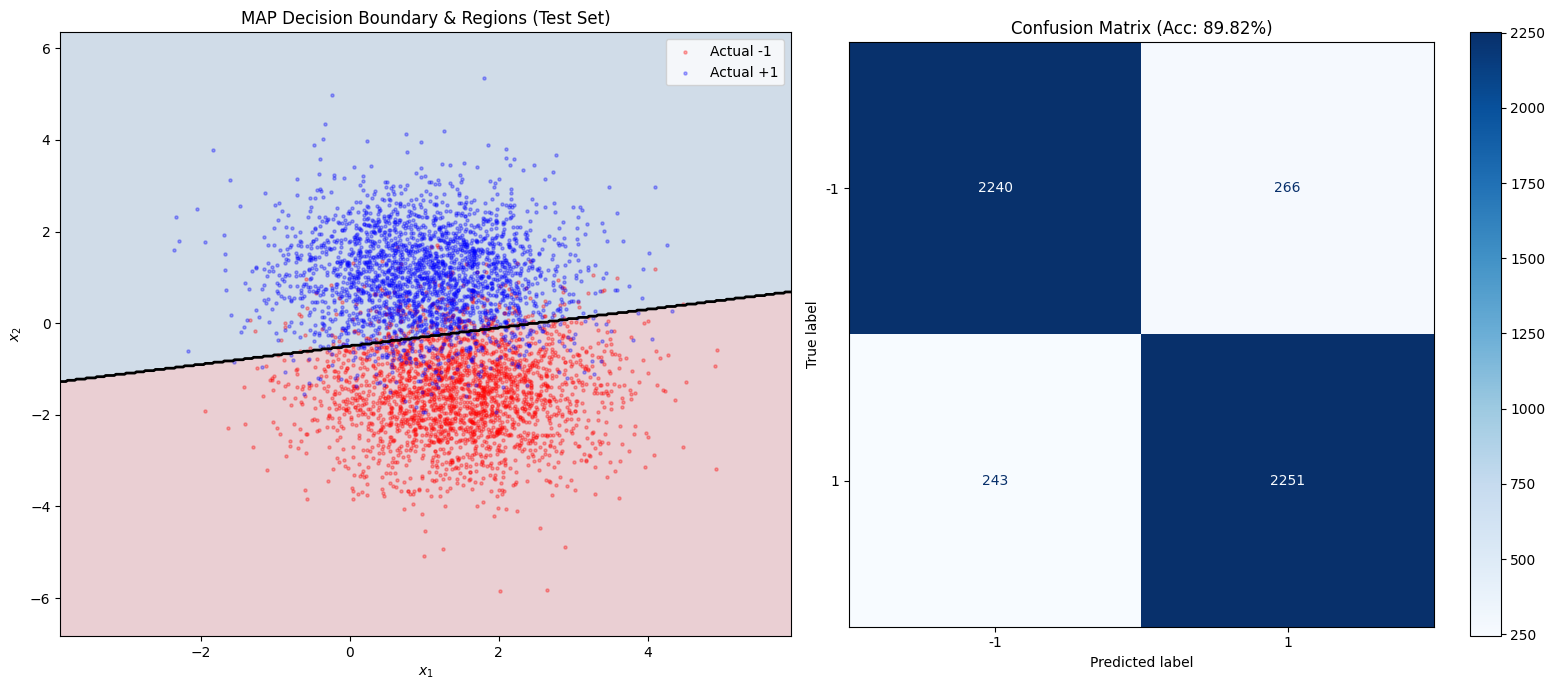